In [2]:
import geopandas as gpd
import rasterio as rio
from shapely.geometry import mapping
from pathlib import Path
from rasterio.plot import show
from rasterio import mask as rio_mask
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
FLAT_SLOPE_THRESHOLD = 10  # degrees
STEEP_SLOPE_THRESHOLD = 30  # degrees

In [4]:
gdf_bunn_moere = gpd.read_file("https://storage.googleapis.com/niva-geodata/MarintNaturKart/bunn_in_kommuner_sea.geojson")

In [5]:
dem_west = rio.open(Path("../DEM25Norge_west_norway.tif"))

# Optional: read first band into array
dem_west_band1 = dem_west.read(1)
print(dem_west.meta)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 8240, 'height': 8800, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 33N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32633"]]'), 'transform': Affine(25.0, 0.0, -48023.91109999921,
       0.0, -25.0, 7020034.509300001)}


In [6]:
gdf_bunn_moere_proj = gdf_bunn_moere.to_crs(dem_west.crs)
# Combine polygons into a single geometry (optional, faster than many small ones)
moere_union = gdf_bunn_moere_proj.union_all()
shapes = [mapping(moere_union)]

clipped_array, clipped_transform = rio_mask.mask(dem_west, shapes=shapes, crop=True)
clipped_meta = dem_west.meta.copy()
clipped_meta.update({
    "height": clipped_array.shape[1],
    "width": clipped_array.shape[2],
    "transform": clipped_transform
})

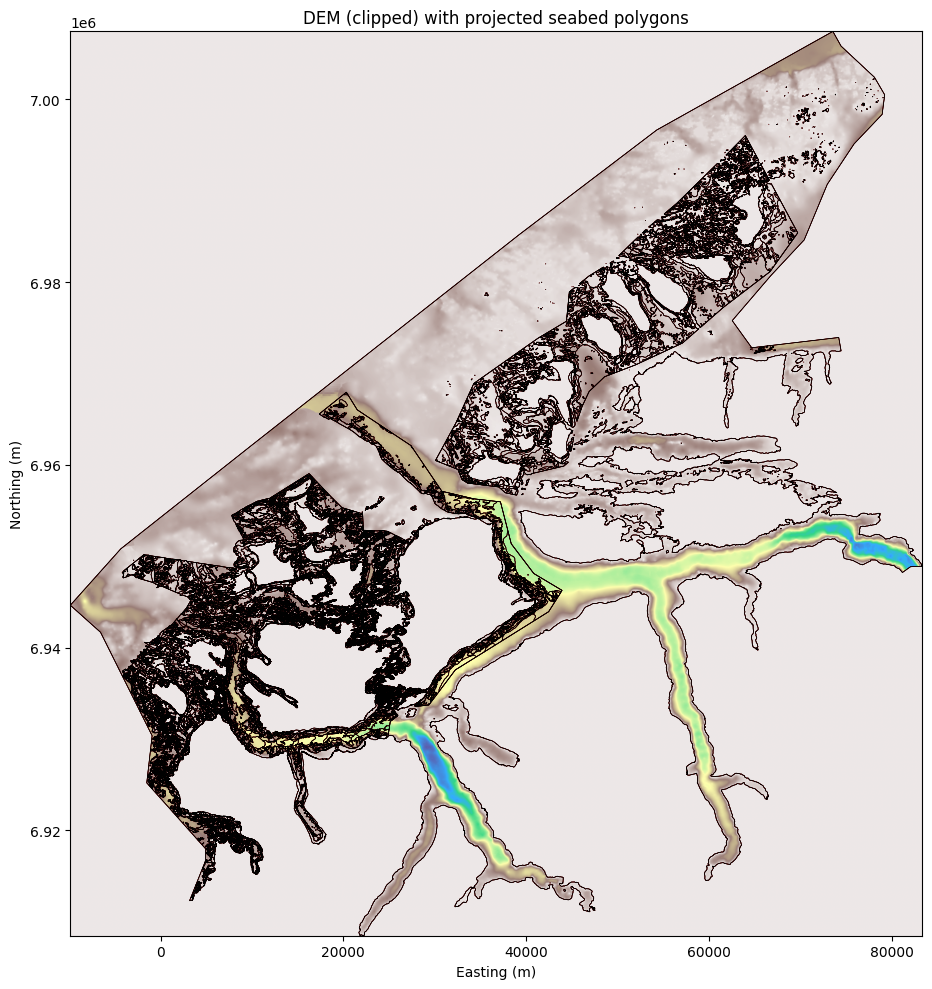

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot clipped raster
show(clipped_array, transform=clipped_transform, ax=ax, cmap="terrain", alpha=0.8)

# Overlay projected GeoDataFrame
gdf_bunn_moere_proj.boundary.plot(ax=ax, color="black", linewidth=0.5)
gdf_bunn_moere_proj.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=0.3)

ax.set_title("DEM (clipped) with projected seabed polygons")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.show()

## Vectorize Polygons for same depths

Low slope can accumelate sediments and sand from rivers etc

In [29]:
dem = clipped_array[0]

# Pixel sizes from affine transform
px = clipped_transform.a  # x pixel size
py = -clipped_transform.e  # y pixel size (make positive)

# Compute gradients (dz/dx, dz/dy) in meters per meter
gy, gx = np.gradient(dem, py, px)
slope = np.sqrt(gx**2 + gy**2)  # rise/run
slope_percent = slope * 100.0

# Valid mask: underwater (negative elevation) and not NaN
valid = np.isfinite(dem) & (dem < 0)

# areas with slope < 10% assumed to accumulate sediment
gentle = valid & (slope_percent < FLAT_SLOPE_THRESHOLD)


bins = np.linspace(-1000, 0, 16, dtype=float)
depth_class = np.digitize(dem, bins, right=False)  # class indices 1..len(bins)
# Zero-out classes where mask not gentle
depth_class[~gentle] = 0

bin_labels = []
for i in range(1, len(bins)):
    bin_labels.append(f"{int(bins[i-1])} to {int(bins[i])} m")


records = []
geoms = []
for (geom, value) in  rio.features.shapes(depth_class.astype(np.int32), mask=depth_class > 0, transform=clipped_transform):
    cls = int(value)
    if cls == 0 or cls > len(bin_labels):
        continue
    geoms.append(geom)
    records.append({"depth_range": bin_labels[cls - 1], "class": cls})

features = [{"type": "Feature", "geometry": g, "properties": r} for g, r in zip(geoms, records)]
gdf_flat_polygons = gpd.GeoDataFrame.from_features(features, crs=gdf_bunn_moere_proj.crs)


In [30]:
gdf_flat_polygons.to_file("depth.geojson", driver="GeoJSON")

## Vectorize Polygons in steep regions

In [ ]:
steep_mask = valid & (slope_percent > STEEP_SLOPE_THRESHOLD)

steep_geoms = []
steep_records = []

for geom, val in rio.features.shapes(
    (steep_mask.astype(np.uint8)),
    mask=steep_mask,
    transform=clipped_transform
):
    if int(val) == 1:
        steep_geoms.append(geom)
        steep_records.append({f"slope_gt_{STEEP_SLOPE_THRESHOLD}": True})

gdf_steep_polygons = gpd.GeoDataFrame.from_features(
    [{"type": "Feature", "geometry": g, "properties": r} for g, r in zip(steep_geoms, steep_records)],
    crs=gdf_bunn_moere_proj.crs
)

print(f"Vectorized steep polygons: {len(gdf_steep_polygons)}")

Vectorized steep polygons: 10047


In [32]:
gdf_steep_polygons = gdf_steep_polygons.to_crs(gdf_bunn_moere.crs)
gdf_flat_polygons = gdf_flat_polygons.to_crs(gdf_bunn_moere.crs)

### Map to Fjord Areas

[Fjordkatalogen dataset](https://kartkatalog.geonorge.no/metadata/fjordkatalogen/d4b28454-ebd6-4425-9a66-00cb2d7e57ed), also see https://kartkatalog.miljodirektoratet.no/Dataset/Details/501. 

The below dataset is a geoparquet dump of the Mdir shapefile to make it reasonable fast to read:)

In [33]:
gdf_fjords = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/fjordkatalogen_omrade.geo.parquet")

In [46]:
# Project fjords to DEM CRS and clip by union polygon
gdf_fjords = gdf_fjords.to_crs(gdf_bunn_moere.crs)
gdf_fjords_moere = gpd.clip(gdf_fjords, moere_union)
# Filter fjord/sund by name and plot on existing ax
mask_fs = gdf_fjords_moere['navn'].str.contains(r'fjord|sund', case=False, na=False)
gdf_fjords_by_def = gdf_fjords_moere[mask_fs]


print(f"Polygons with 'fjord' or 'sund' in name: {len(gdf_fjords_by_def)}")

Polygons with 'fjord' or 'sund' in name: 52


In [57]:
gdf_fjords_flats = gdf_flat_polygons[gdf_flat_polygons.geometry.within(gdf_fjords_by_def.geometry.union_all())].copy()

In [58]:
gdf_fjords_flats.explore().save("predicted_flat_fjords_explore.html")

In [63]:
# Clip predicted flat fjord polygons to areas where gdf_bunn_moere has missing BunnType
_missing_mask = gdf_bunn_moere["BunnType"] == "missing"
missing_geom = gdf_bunn_moere.loc[_missing_mask, ["geometry"]].copy()
gdf_bunn_moere_no_missing = gdf_bunn_moere.loc[~_missing_mask].copy()

gdf_fjords_flats_clipped = gpd.clip(gdf_fjords_flats, missing_geom.union_all())
#gdf_fjords_flats_clipped = gpd.clip(_gdf_fjords_flats_clipped, gdf_bunn_moere_no_missing.union_all())

gdf_fjords_slopes_clipped= gpd.clip(gdf_steep_polygons, missing_geom.union_all())
#gdf_fjords_slopes_clipped = gpd.clip(_gdf_fjords_slopes_clipped, gdf_bunn_moere_no_missing.union_all())

In [60]:
gdf_fjords_slopes_clipped.explore().save("predicted_steep_slopes_fjords.html")
gdf_fjords_flats_clipped.explore().save("predicted_flat_depths_fjords.html")

In [ ]:
for c in gdf_bunn_moere_no_missing.columns:
    if c not in ["geometry", "BunnType", "Source"]:
        gdf_fjords_flats_clipped[c] = "missing"
        gdf_fjords_slopes_clipped[c] = "missing"

gdf_bunn_moere_no_missing['Source'] = 'MarinBunnsedimenter - NGU'

gdf_fjords_flats_clipped['Source'] = f'slope < {FLAT_SLOPE_THRESHOLD}'
gdf_fjords_flats_clipped["BunnType"] = "løsbunn"

gdf_fjords_slopes_clipped['Source'] = f'slope > {STEEP_SLOPE_THRESHOLD}'
gdf_fjords_slopes_clipped["BunnType"] = "fastbunn"


gdf_bunn_moere_no_missing_predicted = gpd.GeoDataFrame(
    pd.concat([gdf_bunn_moere_no_missing, gdf_fjords_flats_clipped, gdf_fjords_slopes_clipped], ignore_index=True),
    crs=gdf_bunn_moere_no_missing.crs,
    geometry='geometry'
)

In [67]:
gdf_bunn_moere_no_missing_predicted.to_file("bunn_moere_with_predicted_fjords.geojson", driver="GeoJSON")

In [68]:
gdf_bunn_moere_no_missing_predicted.explore().save("bunn_moere_with_predicted_fjords_explore.html")

In [ ]:
gdf_bunn_moere.explore().save("bunn_moere_explore.html")

<Axes: >

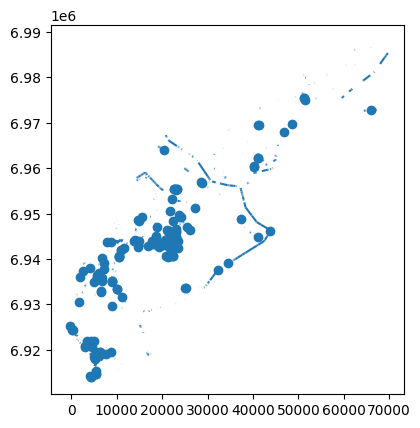

In [ ]:
gdf_fjords_flats_clipped.plot()